## 1. Conexão com o Drive e instalação de dependências


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q --upgrade "torchao>=0.16.0"
!pip install -q scikit-learn peft transformers accelerate openpyxl xlsxwriter


# ── Imports ─────────────────────────────────────────────────────────────────
import gc, re, time, random, unicodedata
from collections import Counter, defaultdict
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (f1_score, accuracy_score, matthews_corrcoef,
                             classification_report, confusion_matrix)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          DataCollatorWithPadding,
                          get_linear_schedule_with_warmup)
from peft import LoraConfig, get_peft_model, TaskType

## 2. Imports e configuração

In [ ]:
# ── Modelo ──────────────────────────────────────────────────────────────────
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
MAX_LENGTH = 384      # cobre 95% dos textos após head+tail truncation

# ── Otimização ──────────────────────────────────────────────────────────────
BATCH_SIZE    = 16
GRAD_ACCUM    = 1
EPOCHS        = 5
LR_LORA       = 5e-5   # LoRA parte de pesos pré-treinados → LR baixo
LR_CLASSIFIER = 1e-4   # cabeça nova → LR mais alto
WARMUP_PCT    = 0.10
SEED          = 42

# ── LoRA ────────────────────────────────────────────────────────────────────
LORA_R         = 32
LORA_ALPHA     = 64    # convenção: alpha = 2 * r
LORA_DROPOUT   = 0.1
TARGET_MODULES = ["query", "key", "value", "output.dense", "intermediate.dense"]

# ── Alvos e classes ─────────────────────────────────────────────────────────
LABEL_SMOOTHING = 0.05
ORDINAL_LAMBDA  = 0.2
MIN_CHARS       = 30
CLASSES         = ["c1", "c234", "c5"]
class_to_idx    = {c: i for i, c in enumerate(CLASSES)}

# ── Validação cruzada ───────────────────────────────────────────────────────
N_FOLDS      = 5
FOLDS_TO_RUN = [0, 1, 2, 3, 4]

# ── Caminhos ────────────────────────────────────────────────────────────────
DRIVE_ROOT = Path("/content/drive/MyDrive/USP/PLN/BERT+LORA")
TRAIN_PATH = DRIVE_ROOT / "dados" / "train.xlsx"
TEST_PATH  = DRIVE_ROOT / "dados" / "test1.xlsx"

## Utilitários

- `set_seed` — reprodutibilidade
- `Logger` — stdout + arquivo
- `limpar_texto` — normalização leve
- `normalizar_grupo` — chave de agrupamento
- `extract/load_trainable_state` — checkpoint só de LoRA + classificador

In [ ]:
def set_seed(s=SEED):
    """Fixa todas as seeds (Python, NumPy, PyTorch, CUDA) para reprodutibilidade.

    Ativa modo determinístico do cuDNN (~5-10% mais lento, mas reprodutível).
    """
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


class Logger:
    """Escreve simultaneamente no stdout e em arquivo."""
    def __init__(self, path):
        self.path = Path(path)
        self.path.parent.mkdir(parents=True, exist_ok=True)
        self._f = open(self.path, "a", encoding="utf-8")

    def __call__(self, msg=""):
        print(msg)
        self._f.write(str(msg) + "\n")
        self._f.flush()

    def close(self):
        self._f.close()


def limpar_texto(texto):
    """Normalização leve: NFC + hifenização + colapso de espaços.

    NÃO remove saudação/rodapé nem mascara entidades — decisão empírica de
    que o BERTimbau se beneficia do texto bruto neste corpus.
    """
    if not isinstance(texto, str):
        return ""
    texto = unicodedata.normalize("NFC", texto)
    texto = re.sub(r"\b(\w+)-\n(\w+)", r"\1\2", texto)   # hifenização de quebra
    texto = re.sub(r"[ \t]+", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def normalizar_grupo(texto, prefix=200):
    """Chave de agrupamento para StratifiedGroupKFold.

    Duas respostas com os primeiros 200 chars normalizados idênticos caem no
    mesmo grupo — captura near-duplicatas e evita vazamento treino↔validação.
    """
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    texto = re.sub(r"\s+", " ", texto)
    texto = re.sub(r"[^a-z0-9\s]", "", texto).strip()
    return texto[:prefix]


def extract_trainable_state(model):
    """Serializa apenas LoRA + classificador (~5M de 110M parâmetros)."""
    keep = {}
    for k, v in model.state_dict().items():
        if ("lora_A" in k or "lora_B" in k
                or "classifier" in k or "modules_to_save" in k):
            keep[k] = v.detach().cpu().clone()
    return keep


def load_trainable_state(model, state):
    """Restaura o state salvo por extract_trainable_state.

    Retorna (chaves_faltando, chaves_inesperadas) para diagnóstico.
    """
    _, unexpected = model.load_state_dict(state, strict=False)
    trainable_keys = {k for k in model.state_dict() if
                      ("lora_A" in k or "lora_B" in k
                       or "classifier" in k or "modules_to_save" in k)}
    faltando = trainable_keys - set(state.keys())
    return faltando, unexpected

## Preparação dos dados

Materializa três visões dos rótulos:
- `Y_soft` — distribuição de classes do grupo  → treino do BERT
- `Y_hard` — classe majoritária do grupo       → estratificação
- `y_raw`  — rótulo individual original        → métrica do EP

E a chave de agrupamento `GROUPS` para StratifiedGroupKFold.

In [ ]:
# ── Carregar e limpar ───────────────────────────────────────────────────────
dados = pd.read_excel(TRAIN_PATH, converters={"resp_text": str, "clarity": str})
dados.columns = ["resp_text", "clarity"]
dados = dados.dropna(subset=["resp_text", "clarity"]).copy()
dados["resp_text"] = dados["resp_text"].astype(str)
dados["clarity"]   = dados["clarity"].astype(str).str.strip().str.lower()

print(f"Total bruto: {len(dados)}")
print("Distribuição original:")
print(dados["clarity"].value_counts())

dados["texto_limpo"] = dados["resp_text"].map(limpar_texto)

# Respostas muito curtas não têm sinal de clareza — descartamos
mask = dados["texto_limpo"].str.len() >= MIN_CHARS
print(f"\nDescartadas por tamanho (< {MIN_CHARS}): {(~mask).sum()}")
dados = dados[mask].reset_index(drop=True)

dados["grupo"] = dados["texto_limpo"].map(normalizar_grupo)


# ── Soft labels por grupo ───────────────────────────────────────────────────
def hard_from_dist(dist_grupo):
    """Reduz a distribuição de um grupo a um rótulo duro (classe majoritária).

    Empates quebrados pela ordem canônica c1 < c234 < c5.
    """
    max_prob = max(dist_grupo.values())
    candidatas = [c for c, p in dist_grupo.items() if p == max_prob]
    for c in CLASSES:
        if c in candidatas:
            return c
    return candidatas[0]


contagem_grupo = defaultdict(Counter)
for g, c in zip(dados["grupo"], dados["clarity"]):
    contagem_grupo[g][c] += 1

mapa_dist = {g: {c: v / sum(cnt.values()) for c, v in cnt.items()}
             for g, cnt in contagem_grupo.items()}
mapa_hard = {g: hard_from_dist(d) for g, d in mapa_dist.items()}

dados["clarity_resolvido"] = dados["grupo"].map(mapa_hard)


def construir_soft_target(row):
    """Vetor (3,) com P(classe) do grupo daquela instância.

    Ex.: grupo [c1, c1, c234] → [0.67, 0.33, 0.00].
    """
    dist = mapa_dist[row["grupo"]]
    vetor = np.zeros(len(CLASSES), dtype=np.float32)
    for c, p in dist.items():
        vetor[class_to_idx[c]] = p
    return vetor


dados["soft_target"] = dados.apply(construir_soft_target, axis=1)

print("\nDistribuição pós-resolução (rótulo duro, referência):")
print(dados["clarity_resolvido"].value_counts())

# ── Diagnóstico de conflitos ────────────────────────────────────────────────
grupos_unicos = dados.groupby("grupo")["clarity"].agg(["nunique", "count"])
grupos_com_conflito = grupos_unicos[grupos_unicos["nunique"] > 1]
print(f"\nGrupos com conflito: {len(grupos_com_conflito)} | "
      f"Amostras: {int(grupos_com_conflito['count'].sum())}")
print(f"Total final: {len(dados)}")

# ── Arrays globais ──────────────────────────────────────────────────────────
X      = dados["texto_limpo"].tolist()
Y_soft = np.stack(dados["soft_target"].values)
Y_hard = dados["clarity_resolvido"].tolist()
GROUPS = dados["grupo"].tolist()

Total bruto: 20092
Distribuição original:
clarity
c5      6892
c234    6853
c1      6347
Name: count, dtype: int64

Descartadas por tamanho (< 30): 213

Distribuição pós-resolução (rótulo duro, referência):
clarity_resolvido
c1      7029
c5      6437
c234    6413
Name: count, dtype: int64

Grupos com conflito: 449 | Amostras: 3027
Total final: 19879


## Dataset, collator e losses

- `TextDataset` — head+tail truncation (metade do budget para cada ponta)
- `SoftLabelCollator` — empilha labels (B, 3) sem padá-los
- `soft_ce_loss` — CE contra distribuição de probabilidades
- `soft_ce_loss_ordinal` — CE + penalidade ordinal (c1 < c234 < c5)
- `build_param_groups` — dois LRs (LoRA baixo, classificador alto)

In [ ]:
class TextDataset(Dataset):
    """Dataset com head+tail truncation (metade do budget para cada ponta)."""
    def __init__(self, texts, soft_targets, tokenizer, max_length=MAX_LENGTH):
        self.texts      = list(texts)
        self.targets    = np.asarray(soft_targets, dtype=np.float32)
        self.tokenizer  = tokenizer
        self.max_length = max_length
        self.cls_id     = tokenizer.cls_token_id
        self.sep_id     = tokenizer.sep_token_id

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self._encode_head_tail(self.texts[idx])
        enc["labels"] = torch.tensor(self.targets[idx], dtype=torch.float32)
        return enc

    def _encode_head_tail(self, text):
        ids = self.tokenizer(text, add_special_tokens=False)["input_ids"]
        budget = self.max_length - 2
        if len(ids) > budget:
            half = budget // 2
            ids = ids[:half] + ids[-half:]
        input_ids = [self.cls_id] + list(ids) + [self.sep_id]
        return {
            "input_ids":      input_ids,
            "attention_mask": [1] * len(input_ids),
        }


class SoftLabelCollator:
    """Como DataCollatorWithPadding, mas empilha labels sem tentar padá-los."""
    def __init__(self, tokenizer):
        self.pad_collator = DataCollatorWithPadding(
            tokenizer, padding=True, return_tensors="pt"
        )

    def __call__(self, features):
        labels = [f.pop("labels") for f in features]
        batch = self.pad_collator(features)
        batch["labels"] = torch.stack(labels, dim=0)   # (B, 3)
        return batch


def soft_ce_loss(logits, soft_targets, weight=None, label_smoothing=0.0):
    """Cross-entropy para alvos suaves (probabilidades, não classes).

    loss = -Σ_c soft_targets[c] * log_softmax(logits)[c], média por amostra.
    """
    if label_smoothing > 0:
        C = soft_targets.size(-1)
        soft_targets = soft_targets * (1.0 - label_smoothing) + label_smoothing / C

    log_probs = F.log_softmax(logits, dim=-1)
    per_class = -(soft_targets * log_probs)

    if weight is not None:
        per_class = per_class * weight.view(1, -1)

    return per_class.sum(dim=-1).mean()


def soft_ce_loss_ordinal(logits, soft_targets, weight=None,
                         label_smoothing=0.0, ordinal_lambda=ORDINAL_LAMBDA):
    """Soft CE + penalidade ordinal.

    O termo ordinal puxa a expectativa da predição para perto da expectativa
    do alvo — ensina que errar c1→c5 é pior que c1→c234.
    """
    ce = soft_ce_loss(logits, soft_targets, weight, label_smoothing)
    ranks = torch.arange(logits.size(-1), dtype=logits.dtype, device=logits.device)
    probs = F.softmax(logits, dim=-1)
    exp_pred = (probs * ranks).sum(dim=-1)
    exp_true = (soft_targets * ranks).sum(dim=-1)
    return ce + ordinal_lambda * ((exp_pred - exp_true) ** 2).mean()


def build_param_groups(model, lr_lora, lr_classifier, weight_decay=0.01):
    """Dois grupos para o AdamW: LoRA (LR baixo) e classificador (LR alto)."""
    lora_p, clf_p = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if "lora_" in name:
            lora_p.append(p)
        elif "classifier" in name or "modules_to_save" in name:
            clf_p.append(p)
    return [
        {"params": lora_p, "lr": lr_lora,       "weight_decay": weight_decay},
        {"params": clf_p,  "lr": lr_classifier, "weight_decay": weight_decay},
    ]

## Baseline oficial e função de treino

- `make_tfidf_logreg` — pipeline do baseline (TF-IDF + LogReg)
- `avaliar_baseline_oficial` — 5-fold SKF em 20 092 amostras cruas
- `treinar_fold` — treina e avalia BERT+LoRA em 1 fold

In [ ]:
def make_tfidf_logreg():
    """Pipeline TF-IDF + LogReg — hiperparâmetros do baseline.ipynb."""
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="word", ngram_range=(1, 2), min_df=5, max_df=0.95,
            max_features=20000, sublinear_tf=True, strip_accents="unicode")),
        ("clf", LogisticRegression(
            C=0.5, class_weight="balanced", max_iter=150,
            solver="saga", tol=1e-3, random_state=SEED)),
    ])


def avaliar_baseline_oficial(path, n_folds=5, seed=SEED):
    """Reproduz o baseline.ipynb do enunciado ao vivo.

    - 5-fold StratifiedKFold (NÃO agrupado)
    - TODAS as amostras cruas de train.xlsx
    - texto cru + rótulo cru individual
    """
    df = pd.read_excel(path, converters={"resp_text": str, "clarity": str})
    X_of, Y_of = df["resp_text"].tolist(), df["clarity"].tolist()

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    accs, f1s = [], []
    print("=" * 72)
    print(f"BASELINE OFICIAL — {n_folds}-fold SKF, {len(X_of)} amostras cruas")
    print("=" * 72)
    for k, (tr, va) in enumerate(skf.split(X_of, Y_of)):
        pipe = make_tfidf_logreg()
        pipe.fit([X_of[i] for i in tr], [Y_of[i] for i in tr])
        preds = pipe.predict([X_of[i] for i in va])
        y_va = [Y_of[i] for i in va]
        accs.append(accuracy_score(y_va, preds))
        f1s.append(f1_score(y_va, preds, average="macro"))
        print(f"  fold {k}: acc={accs[-1]:.4f} | f1_macro={f1s[-1]:.4f}")
    print("-" * 72)
    print(f"Baseline OFICIAL: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print("=" * 72)
    return float(np.mean(accs)), float(np.std(accs))


BASELINE_OFICIAL, BASELINE_OFICIAL_STD = avaliar_baseline_oficial(TRAIN_PATH)

BASELINE OFICIAL — 5-fold SKF, 20092 amostras cruas
  fold 0: acc=0.4588 | f1_macro=0.4564
  fold 1: acc=0.4571 | f1_macro=0.4530
  fold 2: acc=0.4612 | f1_macro=0.4585
  fold 3: acc=0.4629 | f1_macro=0.4600
  fold 4: acc=0.4510 | f1_macro=0.4486
------------------------------------------------------------------------
Baseline OFICIAL: 0.4582 ± 0.0041


In [ ]:
def treinar_fold(train_texts, train_soft, val_texts, val_soft, val_true, log, seed=None):
    """Treina e avalia BERTimbau+LoRA em um único fold.

    Retorna dict com modelo, histórico, métricas do melhor checkpoint,
    predições e logits.
    """
    if seed is None:
        seed = SEED
    set_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    log(f"Dispositivo: {device}")
    if device.type == "cuda":
        log(f"GPU: {torch.cuda.get_device_name(0)} | "
            f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

    # ── Classes ─────────────────────────────────────────────────────────────
    label_encoder = LabelEncoder(); label_encoder.fit(CLASSES)
    num_labels = len(label_encoder.classes_)
    log(f"Classes: {[str(c) for c in label_encoder.classes_]}")

    # ── Modelo + LoRA ───────────────────────────────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    base = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=num_labels)
    lora_cfg = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
        target_modules=TARGET_MODULES,
        modules_to_save=["classifier"])
    model = get_peft_model(base, lora_cfg).to(device)

    treinaveis = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total      = sum(p.numel() for p in model.parameters())
    log(f"Treináveis: {treinaveis:,} / {total:,} ({100*treinaveis/total:.3f}%)")

    # ── Loaders ─────────────────────────────────────────────────────────────
    train_ds = TextDataset(train_texts, train_soft, tokenizer, MAX_LENGTH)
    val_ds   = TextDataset(val_texts,   val_soft,   tokenizer, MAX_LENGTH)
    collator = SoftLabelCollator(tokenizer)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              collate_fn=collator, num_workers=2,
                              persistent_workers=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE * 2,
                              collate_fn=collator, num_workers=2,
                              persistent_workers=True)
    log(f"Treino: {len(train_ds)} | Val: {len(val_ds)} | "
        f"Batches/época: {len(train_loader)}")

    # ── Pesos de classe ─────────────────────────────────────────────────────
    y_hard_train = np.argmax(np.asarray(train_soft), axis=1)
    pesos = compute_class_weight("balanced",
                                 classes=np.arange(num_labels),
                                 y=y_hard_train)
    pesos_t = torch.tensor(pesos, dtype=torch.float, device=device)
    log(f"Pesos de classe: {dict(zip(label_encoder.classes_, pesos.round(4)))}")

    def loss_fn(logits, soft):
        return soft_ce_loss_ordinal(logits, soft, weight=pesos_t,
                                    label_smoothing=LABEL_SMOOTHING,
                                    ordinal_lambda=ORDINAL_LAMBDA)

    # ── Otimizador + scheduler ──────────────────────────────────────────────
    optimizer = AdamW(build_param_groups(model, LR_LORA, LR_CLASSIFIER))
    steps_per_epoch = (len(train_loader) + GRAD_ACCUM - 1) // GRAD_ACCUM
    total_steps = steps_per_epoch * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(WARMUP_PCT * total_steps),
        num_training_steps=total_steps)
    log(f"LRs -> LoRA={LR_LORA} | Classifier={LR_CLASSIFIER} | "
        f"Steps: {total_steps} | warmup: {int(WARMUP_PCT*total_steps)}")

    # ── Loop de treino ──────────────────────────────────────────────────────
    historico = []
    best_f1, best_acc, best_epoch = -1.0, -1.0, -1
    best_state = None
    use_amp = device.type == "cuda"
    t0 = time.time()

    for epoch in range(EPOCHS):
        model.train()
        optimizer.zero_grad()
        epoch_losses = []

        for step, batch in enumerate(train_loader):
            batch = {k: v.to(device) for k, v in batch.items()}
            soft = batch.pop("labels")

            if use_amp:
                with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                    logits = model(**batch).logits
                    loss = loss_fn(logits.float(), soft) / GRAD_ACCUM
            else:
                logits = model(**batch).logits
                loss = loss_fn(logits, soft) / GRAD_ACCUM

            loss.backward()
            epoch_losses.append(loss.item() * GRAD_ACCUM)

            if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step(); optimizer.zero_grad()

        loss_mean = float(np.mean(epoch_losses))

        # ── Avaliação ───────────────────────────────────────────────────────
        model.eval()
        y_pred, y_true_soft = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                soft = batch.pop("labels")
                if use_amp:
                    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                        logits = model(**batch).logits
                else:
                    logits = model(**batch).logits
                logits = logits.float()
                y_pred.extend(logits.argmax(dim=1).cpu().numpy())
                y_true_soft.extend(soft.argmax(dim=1).cpu().numpy())

        y_true = list(val_true)
        acc_soft = accuracy_score(y_true_soft, y_pred)   # diagnóstico
        acc = accuracy_score(y_true, y_pred)
        f1  = f1_score(y_true, y_pred, average="macro")
        mcc = matthews_corrcoef(y_true, y_pred)

        historico.append({"epoch": epoch + 1, "train_loss": loss_mean,
                          "val_f1_macro": f1, "val_acc": acc, "val_mcc": mcc})
        log(f"  [diag] acc soft-argmax={acc_soft:.4f} | acc original={acc:.4f}")
        log(f"Época {epoch+1}/{EPOCHS} | loss={loss_mean:.4f} | "
            f"F1={f1:.4f} | Acc={acc:.4f} | MCC={mcc:.4f}")

        # ── Diagnóstico da loss num batch ───────────────────────────────────
        with torch.no_grad():
            batch_diag = next(iter(val_loader))
            batch_diag = {k: v.to(device) for k, v in batch_diag.items()}
            soft_diag = batch_diag.pop("labels")
            logits_diag = model(**batch_diag).logits.float()
            ce_diag = soft_ce_loss(logits_diag, soft_diag, weight=pesos_t,
                                   label_smoothing=LABEL_SMOOTHING).item()
            ranks = torch.arange(3, dtype=logits_diag.dtype, device=device)
            probs_diag = F.softmax(logits_diag, dim=-1)
            exp_pred = (probs_diag * ranks).sum(-1)
            exp_true = (soft_diag * ranks).sum(-1)
            ord_diag = ((exp_pred - exp_true) ** 2).mean().item()
        log(f"   [diag] CE={ce_diag:.4f} | ordinal={ord_diag:.4f} | λ={ORDINAL_LAMBDA}")

        if acc > best_acc:
            best_f1, best_acc, best_epoch = f1, acc, epoch + 1
            best_state = extract_trainable_state(model)

    elapsed = time.time() - t0
    log(f"\nMelhor época: {best_epoch} | F1={best_f1:.4f} | Acc={best_acc:.4f}")
    log(f"Tempo do fold: {elapsed/60:.1f} min")

    # ── Restaura melhor checkpoint ──────────────────────────────────────────
    if best_state is not None:
        faltando, unexpected = load_trainable_state(model, best_state)
        if faltando:   log(f"[aviso] {len(faltando)} chaves treináveis não restauradas")
        if unexpected: log(f"[aviso] {len(unexpected)} chaves inesperadas")
    model.to(device).eval()

    # ── Reavaliação com melhor checkpoint ───────────────────────────────────
    y_pred, y_true_soft, all_logits = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            soft = batch.pop("labels")
            if use_amp:
                with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                    logits = model(**batch).logits
            else:
                logits = model(**batch).logits
            logits = logits.float()
            all_logits.append(logits.cpu().numpy())
            y_pred.extend(logits.argmax(dim=1).cpu().numpy())
            y_true_soft.extend(soft.argmax(dim=1).cpu().numpy())

    y_true = list(val_true)
    f1_per_class = f1_score(y_true, y_pred, average=None, labels=[0, 1, 2])

    return {
        "model": model, "tokenizer": tokenizer, "label_encoder": label_encoder,
        "history": historico,
        "best_f1": best_f1, "best_acc": best_acc, "best_epoch": best_epoch,
        "val_preds": np.array(y_pred),
        "val_true": np.array(y_true),
        "val_logits": np.concatenate(all_logits, axis=0),
        "elapsed_min": elapsed / 60,
        "best_mcc": float(matthews_corrcoef(y_true, y_pred)),
        "acc_soft_diag": float(acc_soft),
        "f1_c1":   float(f1_per_class[0]),
        "f1_c234": float(f1_per_class[1]),
        "f1_c5":   float(f1_per_class[2]),
    }

## Helpers de visualização

Funções de plot e IC 95% — definidas aqui para serem reutilizadas
tanto no loop dos folds quanto no treino final.

In [ ]:
def tabela_folds(resultados):
    """Tabela consolidada por fold, com média e std."""
    df = pd.DataFrame(resultados).T.rename(columns={
        "baseline_oficial": "oficial",
        "baseline_local":   "local_tfidf",
        "bert_acc":         "bert",
        "bert_f1":          "f1_bert",
        "best_epoch":       "ep",
        "delta_oficial":    "Δ_oficial",
        "delta_local":      "Δ_local",
        "elapsed_min":      "min",
    })
    cols = ["oficial", "local_tfidf", "bert", "f1_bert", "ep",
            "Δ_oficial", "Δ_local", "min"]
    df = df[cols]
    df.loc["média"] = df.mean(numeric_only=True)
    df.loc["std"]   = df.std(numeric_only=True)
    return df.round(4)


def ic95(valores):
    """Intervalo de confiança 95% via t-Student."""
    n = len(valores)
    m, s = np.mean(valores), np.std(valores, ddof=1)
    h = stats.t.ppf(0.975, df=n - 1) * s / np.sqrt(n)
    return m, m - h, m + h


def plot_confusao(preds, true, classes=CLASSES, titulo=""):
    """Matriz de confusão: contagens + normalizada."""
    n = len(classes)
    cm = confusion_matrix(true, preds, labels=list(range(n)))
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, mat, tit, fmt in [(axes[0], cm, "Contagens", "d"),
                              (axes[1], cm_norm, "Normalizada", ".2f")]:
        ax.imshow(mat, cmap="Blues")
        ax.set_xticks(range(n)); ax.set_yticks(range(n))
        ax.set_xticklabels(classes); ax.set_yticklabels(classes)
        ax.set_xlabel("Predito"); ax.set_ylabel("Real"); ax.set_title(tit)
        for i in range(n):
            for j in range(n):
                ax.text(j, i, format(mat[i, j], fmt),
                        ha="center", va="center",
                        color="white" if mat[i, j] > mat.max() / 2 else "black")
    if titulo: fig.suptitle(titulo)
    plt.tight_layout(); plt.show()


def plot_confianca(preds, true, logits):
    """Histograma de confiança (acertos vs erros) + acurácia por faixa."""
    probs = F.softmax(torch.tensor(logits), dim=-1).numpy()
    conf  = probs.max(axis=1)
    corr  = (preds == true)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(conf[corr],  bins=20, alpha=0.6, label=f"acertos (n={corr.sum()})")
    ax.hist(conf[~corr], bins=20, alpha=0.6, label=f"erros (n={(~corr).sum()})")
    ax.set_xlabel("Confiança (max softmax)"); ax.set_ylabel("Contagem")
    ax.set_title("Acertos vs erros por faixa de confiança"); ax.legend()
    plt.show()

    print("\nAcurácia por faixa de confiança:")
    for lo, hi in [(0.0, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.0)]:
        m = (conf >= lo) & (conf < hi)
        if m.sum() > 0:
            print(f"  [{lo:.1f}–{hi:.1f}): acc={corr[m].mean():.3f} (n={m.sum()})")

## Execução dos 5 folds

- StratifiedGroupKFold com verificação explícita de vazamento
- Baseline local (TF-IDF + LogReg nas mesmas condições)
- BERT+LoRA com soft labels
- Diagnóstico visual agregado (matriz de confusão + confiança)

In [ ]:
resultados_por_fold = {}
preds_all, true_all, logits_all = [], [], []

print(f"Total: {len(X)} | Distribuição: "
      f"{pd.Series(Y_hard).value_counts().to_dict()}")

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
splits = list(sgkf.split(X, Y_hard, groups=GROUPS))

# Verificação explícita de vazamento
for i, (tr, va) in enumerate(splits):
    g_tr = set(GROUPS[j] for j in tr)
    g_va = set(GROUPS[j] for j in va)
    assert not (g_tr & g_va), f"Vazamento de grupo no fold {i}!"

for fold in FOLDS_TO_RUN:
    fold_out = DRIVE_ROOT / "resultados" / f"fold_{fold}"
    fold_out.mkdir(parents=True, exist_ok=True)
    log = Logger(fold_out / "log.txt")
    log("=" * 72); log(f"FOLD {fold}"); log("=" * 72)

    tr_idx, va_idx = splits[fold]
    X_tr, X_va = [X[i] for i in tr_idx], [X[i] for i in va_idx]
    Y_tr_soft, Y_va_soft = Y_soft[tr_idx], Y_soft[va_idx]
    Y_tr_hard = [Y_hard[i] for i in tr_idx]
    Y_va_hard = [Y_hard[i] for i in va_idx]

    log(f"Treino: {len(X_tr)} | Val: {len(X_va)}")

    # Baseline local (mesmas condições do BERT)
    pipe_local = make_tfidf_logreg().fit(X_tr, Y_tr_hard)
    acc_baseline_local = pipe_local.score(X_va, Y_va_hard)
    log(f"Baseline LOCAL (limpo + hard): {acc_baseline_local:.4f}")

    # BERT+LoRA
    log("\n--- BERT+LoRA ---")
    Y_va_true = [class_to_idx[dados["clarity"].iloc[i]] for i in va_idx]
    result = treinar_fold(X_tr, Y_tr_soft, X_va, Y_va_soft, Y_va_true, log)

    log("\nRELATÓRIO BERT+LoRA:")
    log(classification_report(result["val_true"], result["val_preds"],
                              target_names=result["label_encoder"].classes_,
                              digits=4, zero_division=0))

    delta_local   = result["best_acc"] - acc_baseline_local
    delta_oficial = result["best_acc"] - BASELINE_OFICIAL
    log("\n" + "=" * 72); log("COMPARAÇÃO"); log("=" * 72)
    log(f"Baseline OFICIAL : {BASELINE_OFICIAL:.4f}")
    log(f"Baseline LOCAL   : {acc_baseline_local:.4f}")
    log(f"BERT+LoRA        : {result['best_acc']:.4f}")
    log(f"Δ vs OFICIAL     : {delta_oficial:+.4f}")
    log(f"Δ vs LOCAL       : {delta_local:+.4f}")

    pd.DataFrame(result["history"]).to_csv(fold_out / "history.csv", index=False)

    resultados_por_fold[fold] = {
        "fold":             fold,
        "baseline_oficial": BASELINE_OFICIAL,
        "baseline_local":   float(acc_baseline_local),
        "bert_acc":         float(result["best_acc"]),
        "bert_f1":          float(result["best_f1"]),
        "best_epoch":       int(result["best_epoch"]),
        "delta_oficial":    float(delta_oficial),
        "delta_local":      float(delta_local),
        "elapsed_min":      float(result["elapsed_min"]),
    }

    preds_all.extend(result["val_preds"])
    true_all.extend(result["val_true"])
    logits_all.append(result["val_logits"])

    result["model"].save_pretrained(fold_out / "lora_adapter")
    result["tokenizer"].save_pretrained(fold_out / "lora_adapter")
    log.close()

    del result, pipe_local
    gc.collect(); torch.cuda.empty_cache()

preds_all  = np.array(preds_all)
true_all   = np.array(true_all)
logits_all = np.concatenate(logits_all, axis=0)

Total: 19879 | Distribuição: {'c1': 7029, 'c5': 6437, 'c234': 6413}
FOLD 0
Treino: 15886 | Val: 3993
Baseline LOCAL (limpo + hard): 0.4728

--- BERT+LoRA ---
Dispositivo: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition | VRAM: 102.0 GB
Classes: ['c1', 'c234', 'c5']


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

Treináveis: 5,310,723 / 114,236,166 (4.649%)
Treino: 16038 | Val: 3841 | Batches/época: 1003
Pesos de classe: {np.str_('c1'): np.float64(0.9236), np.str_('c234'): np.float64(1.0546), np.str_('c5'): np.float64(1.0318)}
LRs -> LoRA=5e-05 | Classifier=0.0001 | Steps: 5015 | warmup: 501
  [diag] acc soft-argmax=0.4311 | acc original=0.4324
Época 1/5 | loss=1.1936 | F1=0.4079 | Acc=0.4324 | MCC=0.1557
   [diag] CE=1.0637 | ordinal=0.4646 | λ=0.2
  [diag] acc soft-argmax=0.4616 | acc original=0.4595
Época 2/5 | loss=1.1511 | F1=0.4525 | Acc=0.4595 | MCC=0.1923
   [diag] CE=1.0182 | ordinal=0.4104 | λ=0.2
  [diag] acc soft-argmax=0.4705 | acc original=0.4671
Época 3/5 | loss=1.1202 | F1=0.4637 | Acc=0.4671 | MCC=0.1986
   [diag] CE=1.0825 | ordinal=0.4875 | λ=0.2
  [diag] acc soft-argmax=0.4723 | acc original=0.4718
Época 4/5 | loss=1.0910 | F1=0.4697 | Acc=0.4718 | MCC=0.2059
   [diag] CE=1.0793 | ordinal=0.4842 | λ=0.2
  [diag] acc soft-argmax=0.4621 | acc original=0.4645
Época 5/5 | loss=1

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

Treináveis: 5,310,723 / 114,236,166 (4.649%)
Treino: 15699 | Val: 4180 | Batches/época: 982
Pesos de classe: {np.str_('c1'): np.float64(0.9754), np.str_('c234'): np.float64(1.0171), np.str_('c5'): np.float64(1.0085)}
LRs -> LoRA=5e-05 | Classifier=0.0001 | Steps: 4910 | warmup: 491
  [diag] acc soft-argmax=0.4947 | acc original=0.4311
Época 1/5 | loss=1.1934 | F1=0.4137 | Acc=0.4311 | MCC=0.1565
   [diag] CE=1.0786 | ordinal=0.5398 | λ=0.2
  [diag] acc soft-argmax=0.4711 | acc original=0.4603
Época 2/5 | loss=1.1515 | F1=0.4541 | Acc=0.4603 | MCC=0.1929
   [diag] CE=1.0460 | ordinal=0.4873 | λ=0.2
  [diag] acc soft-argmax=0.5019 | acc original=0.4605
Época 3/5 | loss=1.1172 | F1=0.4576 | Acc=0.4605 | MCC=0.1917
   [diag] CE=1.0118 | ordinal=0.4543 | λ=0.2
  [diag] acc soft-argmax=0.4897 | acc original=0.4579
Época 4/5 | loss=1.0882 | F1=0.4545 | Acc=0.4579 | MCC=0.1878
   [diag] CE=1.0164 | ordinal=0.4547 | λ=0.2
  [diag] acc soft-argmax=0.4904 | acc original=0.4545
Época 5/5 | loss=1.

In [ ]:
# ── Resumo dos folds ────────────────────────────────────────────────────────
df_folds = pd.DataFrame(resultados_por_fold).T
df_folds.loc["media"] = df_folds.mean(numeric_only=True)
df_folds.loc["std"]   = df_folds.std(numeric_only=True)
df_folds.to_csv(DRIVE_ROOT / "resultados" / "bert_lora_5folds.csv")

print("\n" + "=" * 90)
print("RESUMO DOS FOLDS")
print("=" * 90)
print(tabela_folds(resultados_por_fold).to_string())

# EPOCHS_FIXO derivado da mediana dos best_epoch
best_epochs = [int(resultados_por_fold[f]["best_epoch"]) for f in FOLDS_TO_RUN]
EPOCHS_FIXO = int(round(np.median(best_epochs)))
print("\n" + "=" * 90); print("DERIVAÇÃO DE EPOCHS_FIXO"); print("=" * 90)
print(f"  best_epoch por fold : {best_epochs}")
print(f"  mediana             : {np.median(best_epochs):.1f}")
print(f"  → EPOCHS_FIXO       : {EPOCHS_FIXO}")

# Resumo com IC 95%
print("\n" + "=" * 90)
print("RESUMO FINAL — MÉDIAS ± DESVIO (5 folds)")
print("=" * 90)
for nome, col in [("Baseline OFICIAL", "baseline_oficial"),
                  ("Baseline LOCAL",   "baseline_local"),
                  ("BERT+LoRA",        "bert_acc")]:
    vals = [resultados_por_fold[f][col] for f in FOLDS_TO_RUN]
    m, lo, hi = ic95(vals)
    print(f"  {nome:<18}: {m:.4f}  [IC95: {lo:.4f}, {hi:.4f}]")
media = df_folds.loc["media"]
print(f"\n  Δ BERT vs OFICIAL : {media['bert_acc'] - BASELINE_OFICIAL:+.4f}")
print(f"  Δ BERT vs LOCAL   : {media['bert_acc'] - media['baseline_local']:+.4f}")


RESUMO DOS FOLDS
       oficial  local_tfidf    bert  f1_bert   ep  Δ_oficial  Δ_local     min
0       0.4582       0.4728  0.4616   0.4616  4.0     0.0034  -0.0113  3.3274
1       0.4582       0.4736  0.4492   0.4442  4.0    -0.0090  -0.0244  3.3032
2       0.4582       0.4897  0.4547   0.4477  2.0    -0.0035  -0.0351  3.3198
3       0.4582       0.4619  0.4718   0.4697  4.0     0.0136   0.0099  3.3296
4       0.4582       0.4622  0.4605   0.4576  3.0     0.0023  -0.0017  3.2839
média   0.4582       0.4720  0.4595   0.4562  3.4     0.0013  -0.0125  3.3128
std     0.0000       0.0102  0.0075   0.0092  0.8     0.0075   0.0159  0.0172

DERIVAÇÃO DE EPOCHS_FIXO
  best_epoch por fold : [4, 4, 2, 4, 3]
  mediana             : 4.0
  → EPOCHS_FIXO       : 4

RESUMO FINAL — MÉDIAS ± DESVIO (5 folds)
  Baseline OFICIAL  : 0.4582  [IC95: 0.4582, 0.4582]
  Baseline LOCAL    : 0.4720  [IC95: 0.4579, 0.4862]
  BERT+LoRA         : 0.4595  [IC95: 0.4491, 0.4700]

  Δ BERT vs OFICIAL : +0.0013
  Δ BE


DIAGNÓSTICO VISUAL — 5 folds agregados


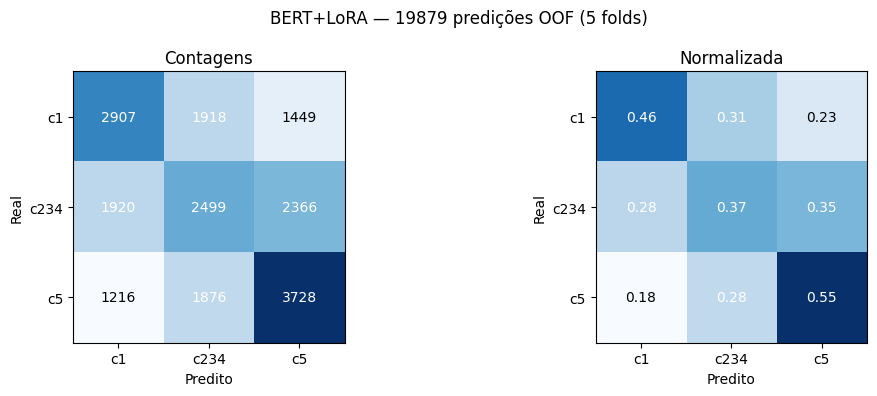

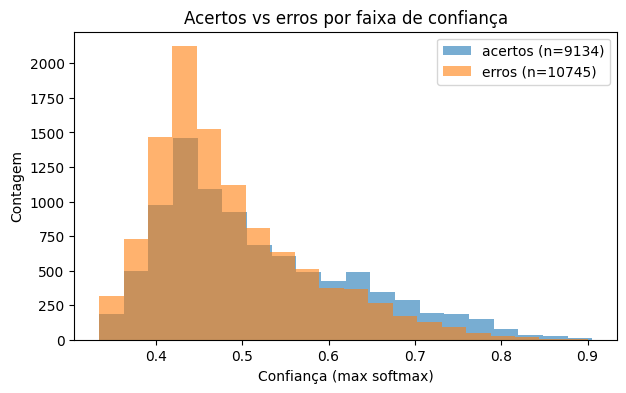


Acurácia por faixa de confiança:
  [0.0–0.4): acc=0.391 (n=2346)
  [0.4–0.6): acc=0.434 (n=14079)
  [0.6–0.8): acc=0.600 (n=3295)
  [0.8–1.0): acc=0.780 (n=159)


In [ ]:
# ── Diagnóstico visual agregado ─────────────────────────────────────────────
print("\n" + "=" * 90)
print("DIAGNÓSTICO VISUAL — 5 folds agregados")
print("=" * 90)

plot_confusao(preds_all, true_all,
              titulo=f"BERT+LoRA — {len(preds_all)} predições OOF (5 folds)")
plot_confianca(preds_all, true_all, logits_all)

---

## Treino final

Treina em 100% dos dados usando `EPOCHS_FIXO` (mediana dos folds) e gera
`teste_rotulado.xlsx`.

In [ ]:
def treinar_final(train_texts, train_soft, epochs_fixo, log):
    """Treina BERT+LoRA em 100% dos dados por um número fixo de épocas.

    `epochs_fixo` = mediana dos best_epoch observados nos 5 folds.
    """
    set_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    label_encoder = LabelEncoder(); label_encoder.fit(CLASSES)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    base = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(label_encoder.classes_))
    lora_cfg = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
        target_modules=TARGET_MODULES,
        modules_to_save=["classifier"])
    model = get_peft_model(base, lora_cfg).to(device)

    train_ds = TextDataset(train_texts, train_soft, tokenizer, MAX_LENGTH)
    collator = SoftLabelCollator(tokenizer)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              collate_fn=collator, num_workers=2,
                              persistent_workers=True)

    y_hard_train = np.argmax(np.asarray(train_soft), axis=1)
    pesos = compute_class_weight("balanced",
                                 classes=np.arange(len(CLASSES)),
                                 y=y_hard_train)
    pesos_t = torch.tensor(pesos, dtype=torch.float, device=device)

    def loss_fn(logits, soft):
        return soft_ce_loss_ordinal(logits, soft, weight=pesos_t,
                                    label_smoothing=LABEL_SMOOTHING,
                                    ordinal_lambda=ORDINAL_LAMBDA)

    optimizer = AdamW(build_param_groups(model, LR_LORA, LR_CLASSIFIER))
    steps_per_epoch = (len(train_loader) + GRAD_ACCUM - 1) // GRAD_ACCUM
    total_steps = steps_per_epoch * epochs_fixo
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(WARMUP_PCT * total_steps),
        num_training_steps=total_steps)

    use_amp = device.type == "cuda"
    model.train(); optimizer.zero_grad()

    for epoch in range(epochs_fixo):
        epoch_losses = []
        for step, batch in enumerate(train_loader):
            batch = {k: v.to(device) for k, v in batch.items()}
            soft  = batch.pop("labels")
            if use_amp:
                with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                    logits = model(**batch).logits
                    loss = loss_fn(logits.float(), soft) / GRAD_ACCUM
            else:
                logits = model(**batch).logits
                loss = loss_fn(logits, soft) / GRAD_ACCUM
            loss.backward()
            epoch_losses.append(loss.item() * GRAD_ACCUM)
            if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step(); optimizer.zero_grad()
        log(f"Época {epoch+1}/{epochs_fixo} | loss={np.mean(epoch_losses):.4f}")

    return model, tokenizer, label_encoder

In [ ]:
# ── Preparação: treino completo + soft targets ──────────────────────────────
def grupo_dist(series):
    """Distribuição {classe: prob} dos rótulos de um grupo."""
    counts = Counter(series)
    total  = sum(counts.values())
    return {c: v / total for c, v in counts.items()}


def construir_soft_target_grupo(dist_grupo):
    """Vetor (3,) de probabilidades na ordem canônica CLASSES."""
    vetor = np.zeros(len(CLASSES), dtype=np.float32)
    for classe, prob in dist_grupo.items():
        vetor[class_to_idx[classe]] = prob
    return vetor


dados_full = pd.read_excel(TRAIN_PATH, converters={"resp_text": str, "clarity": str})
dados_full.columns = ["resp_text", "clarity"]
dados_full = dados_full.dropna(subset=["resp_text", "clarity"]).copy()
dados_full["resp_text"] = dados_full["resp_text"].astype(str)
dados_full["clarity"]   = dados_full["clarity"].astype(str).str.strip().str.lower()
dados_full["texto_limpo"] = dados_full["resp_text"].map(limpar_texto)
dados_full = dados_full[
    dados_full["texto_limpo"].str.len() >= MIN_CHARS
].reset_index(drop=True)
dados_full["grupo"] = dados_full["texto_limpo"].map(normalizar_grupo)

mapa_dist_full = {}
for grupo_id, sub in dados_full.groupby("grupo"):
    mapa_dist_full[grupo_id] = grupo_dist(sub["clarity"])

dados_full["soft_target"] = dados_full["grupo"].map(
    lambda g: construir_soft_target_grupo(mapa_dist_full[g]))

X_full      = dados_full["texto_limpo"].tolist()
Y_full_soft = np.stack(dados_full["soft_target"].values)

print(f"Total treino final: {len(X_full)}")
print(f"Distribuição crua : {dict(Counter(dados_full['clarity']))}")
print(f"Grupos únicos     : {dados_full['grupo'].nunique()}")

Total treino final: 19879
Distribuição crua : {'c5': 6820, 'c1': 6274, 'c234': 6785}
Grupos únicos     : 16903


In [ ]:
# ── Treino final ────────────────────────────────────────────────────────────
assert "EPOCHS_FIXO" in globals(), \
    "Rode a célula de resumo dos folds primeiro — ela define EPOCHS_FIXO."

final_out = DRIVE_ROOT / "resultados" / "final"
final_out.mkdir(parents=True, exist_ok=True)
log_final = Logger(final_out / "log_final.txt")

log_final("=" * 72)
log_final(f"TREINO FINAL — {datetime.now():%Y-%m-%d %H:%M:%S}")
log_final("=" * 72)
log_final(f"Amostras: {len(X_full)} | Épocas: {EPOCHS_FIXO} (mediana dos folds)")

model_final, tok_final, le_final = treinar_final(
    X_full, Y_full_soft, EPOCHS_FIXO, log_final)

model_final.save_pretrained(final_out / "lora_adapter")
tok_final.save_pretrained(final_out / "lora_adapter")
log_final(f"Adapter salvo em: {final_out / 'lora_adapter'}")

TREINO FINAL — 2026-10-04 21:57:02
Amostras: 19879 | Épocas: 4 (mediana dos folds)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

Época 1/4 | loss=1.1879
Época 2/4 | loss=1.1417
Época 3/4 | loss=1.1096
Época 4/4 | loss=1.0841
Adapter salvo em: /content/drive/MyDrive/USP/PLN/BERT+LORA/resultados/final/lora_adapter


In [ ]:
# ── Predição no teste + planilha ────────────────────────────────────────────

df_test_original = pd.read_excel(TEST_PATH)          # leitura CRUA, sem filtros
n_original = len(df_test_original)
log_final(f"Teste original: {n_original} linhas | colunas: {list(df_test_original.columns)}")

# Preserva 'resp_text' como string, sem descartar nada
df_test = df_test_original.copy()
df_test["resp_text"] = df_test["resp_text"].fillna("").astype(str)

# Se por acaso o arquivo já vier com uma coluna 'clarity' (vazia ou não), descartamos
# — a saída terá uma 'clarity' nova, predita pelo modelo.
if "clarity" in df_test.columns:
    df_test = df_test.drop(columns=["clarity"])

# Normalização leve para inferência (NaN já virou "" acima)
df_test["texto_limpo"] = df_test["resp_text"].map(limpar_texto)

log_final(f"Teste para inferência: {len(df_test)} amostras "
          f"(vazios/textos curtos NÃO foram descartados)")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_final.to(device).eval()

dummy_soft = np.zeros((len(df_test), len(CLASSES)), dtype=np.float32)
test_ds = TextDataset(df_test["texto_limpo"].tolist(), dummy_soft,
                      tok_final, MAX_LENGTH)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE * 2,
                         collate_fn=SoftLabelCollator(tok_final),
                         num_workers=2, persistent_workers=True)

all_preds = []
use_amp = device.type == "cuda"
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        batch.pop("labels", None)
        if use_amp:
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                logits = model_final(**batch).logits
        else:
            logits = model_final(**batch).logits
        all_preds.extend(logits.float().argmax(dim=1).cpu().numpy())

Y_pred_labels = le_final.inverse_transform(all_preds)
log_final(f"Distribuição predita: {dict(Counter(Y_pred_labels))}")

# ── Reconstrói a saída preservando a estrutura original ─────────────────────
saida = df_test_original.copy()
saida["resp_text"] = saida["resp_text"].fillna("").astype(str)

# Se o original já tinha 'clarity', sobrescrevemos com a predição;
# senão, adicionamos a coluna no final.
saida["clarity"] = Y_pred_labels

# Garante exatamente as colunas esperadas (resp_text, clarity), nesta ordem.
saida = saida[["resp_text", "clarity"]]

saida_path = DRIVE_ROOT / "teste_rotulado.xlsx"
saida.to_excel(saida_path, index=False)

# ── Validação anti-penalidade (-20%) ────────────────────────────────────────
orig_check = pd.read_excel(TEST_PATH)
out_check  = pd.read_excel(saida_path)

assert len(orig_check) == len(out_check), (
    f"Contagem de linhas divergente: original={len(orig_check)}, saída={len(out_check)}")
assert list(out_check.columns) == ["resp_text", "clarity"], (
    f"Colunas erradas: {list(out_check.columns)}")
assert set(out_check["clarity"].unique()) <= {"c1", "c234", "c5"}, (
    f"Rótulos inválidos: {set(out_check['clarity'].unique())}")
assert (orig_check["resp_text"].fillna("").astype(str).values
        == out_check["resp_text"].fillna("").astype(str).values).all(), (
    "Ordem/conteúdo de resp_text foi alterado — a planilha deve preservar a ordem original")

log_final("✓ Validação pós-escrita: OK (linhas, colunas, rótulos e ordem)")
log_final(f"✓ Salvo em: {saida_path}")
log_final.close()

print(f"\n✓ Planilha gerada: {saida_path}")
print(f"  Linhas : {len(saida)}  (original: {n_original})")
print(f"  Colunas: {list(saida.columns)}")
print(f"  Distribuição: {dict(Counter(saida['clarity']))}")
print(f"\nPrimeiras linhas:")
print(saida.head().to_string())

Teste original: 900 linhas | colunas: ['resp_text', 'clarity']
Teste para inferência: 900 amostras (vazios/textos curtos NÃO foram descartados)
Distribuição predita: {np.str_('c234'): 270, np.str_('c5'): 349, np.str_('c1'): 281}
✓ Validação pós-escrita: OK (linhas, colunas, rótulos e ordem)
✓ Salvo em: /content/drive/MyDrive/USP/PLN/BERT+LORA/teste_rotulado.xlsx

✓ Planilha gerada: /content/drive/MyDrive/USP/PLN/BERT+LORA/teste_rotulado.xlsx
  Linhas : 900  (original: 900)
  Colunas: ['resp_text', 'clarity']
  Distribuição: {'c234': 270, 'c5': 349, 'c1': 281}

Primeiras linhas:
                                                                                                                                                                                                                                                                                                                                                                                                                               